# 2.1 Iterative MPC (iMPC)

Re-linearize around solution trajectory, re-solve, repeat until convergence.

**iMPC Algorithm:**
1. Start with guess trajectory
2. Linearize at guess -> solve QP -> new trajectory
3. Re-linearize at new trajectory -> solve again
4. Repeat until max change < tolerance

Warm-start: shift previous solution by 1 step.

Converged in 2 iterations


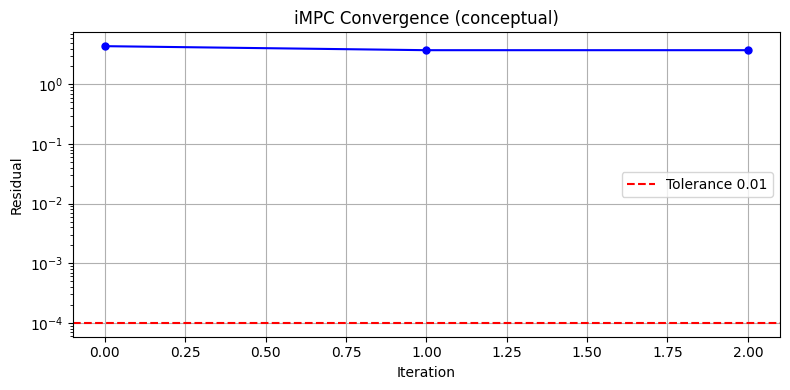

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

# Conceptual demo: convergence of iterative process
def solve_iterative(A, b, x0, max_iter=10, tol=1e-4):
    x = x0.copy()
    history = [np.linalg.norm(A@x - b)]
    for i in range(max_iter):
        x = np.linalg.solve(A.T@A + 0.1*np.eye(len(x)), A.T@b + 0.1*x)
        err = np.linalg.norm(A@x - b)
        history.append(err)
        if abs(history[-1] - history[-2]) < tol:
            break
    return history

A = np.random.randn(20, 10)
b = np.random.randn(20)
x0 = np.zeros(10)
history = solve_iterative(A, b, x0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history, 'b-o', markersize=5)
ax.axhline(1e-4, color='r', linestyle='--', label='Tolerance 0.01')
ax.set_xlabel('Iteration'); ax.set_ylabel('Residual')
ax.set_title('iMPC Convergence (conceptual)')
ax.legend(); ax.grid(True)
print('Converged in %d iterations' % (len(history)-1))
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/2.1_impc.png', dpi=100, bbox_inches='tight')
plt.show()


# Summary

iMPC re-linearizes at each iteration. Typically converges in 2-3 iterations. Warm-start reduces iterations significantly.